In [1]:
import sys
sys.path.append('../')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from src.core.preprocessor import prepare_give_me_some_credit_grandmaster

plt.style.use('seaborn-v0_8-darkgrid')

C:\Workspace\projects\ml\fintech-credit-risk-xai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


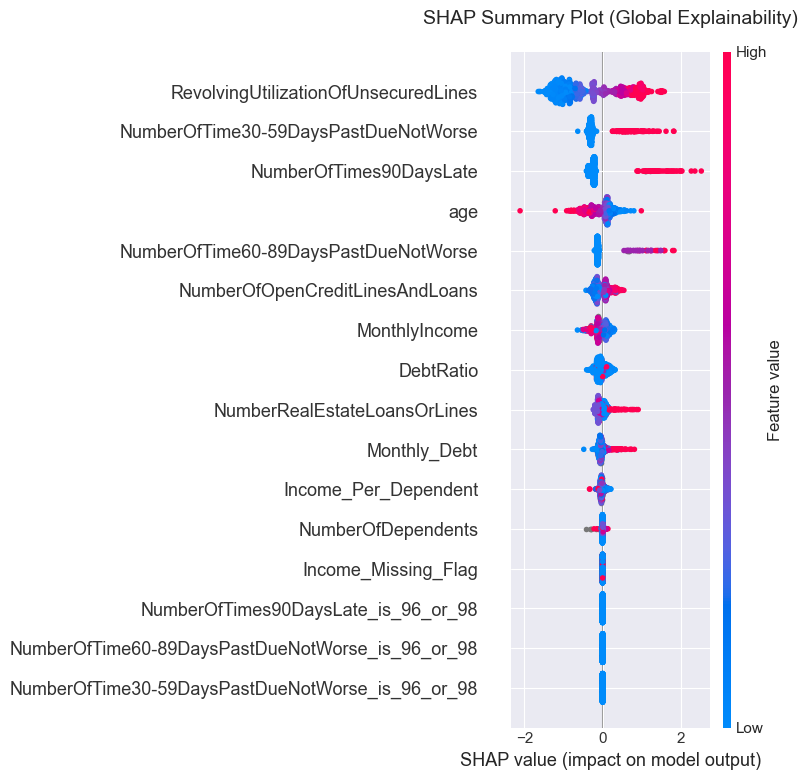

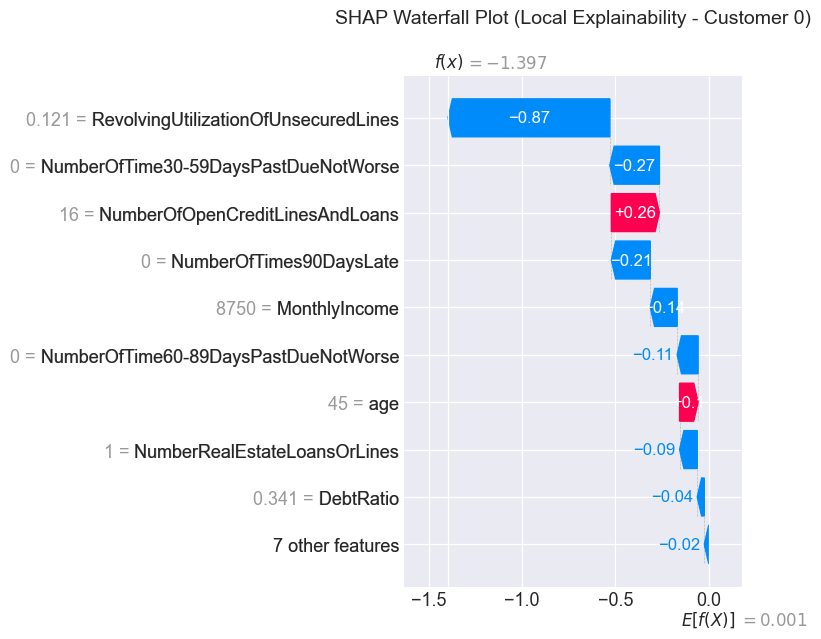

In [2]:
file_path = '../data/raw/Give Me Some Credit/cs-training.csv'
X_train, X_test, y_train, y_test, feature_names = prepare_give_me_some_credit_grandmaster(file_path)

imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_gm = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    n_jobs=-1
)
xgb_gm.fit(X_train, y_train)

X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_sample = X_test_df.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(xgb_gm)
shap_values = explainer(X_test_sample)

plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot (Global Explainability)', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary", dpi=300, bbox_inches="tight")
plt.show()

sample_idx = 0
plt.figure()
shap.plots.waterfall(shap_values[sample_idx], max_display=10, show=False)
plt.title(f'SHAP Waterfall Plot (Local Explainability - Customer {sample_idx})', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig("shap_waterfall", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

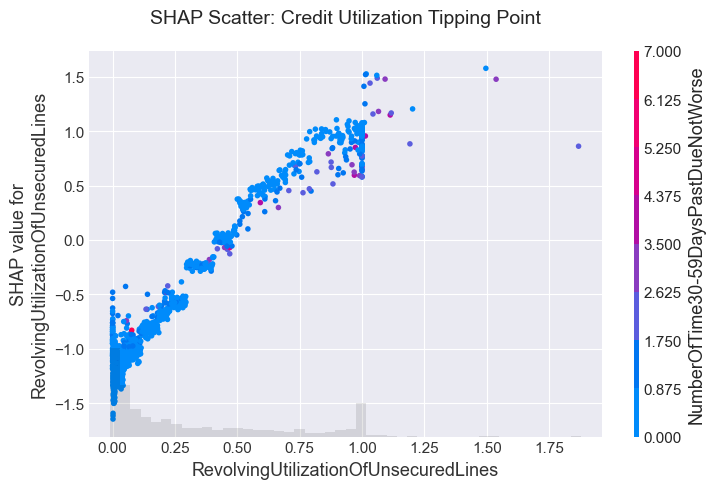

In [3]:
plt.figure(figsize=(10, 6))
shap.plots.scatter(
    shap_values[:, "RevolvingUtilizationOfUnsecuredLines"], 
    color=shap_values[:, "NumberOfTime30-59DaysPastDueNotWorse"], 
    show=False
)
plt.title('SHAP Scatter: Credit Utilization Tipping Point', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig("shap_scatter", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
customer_idx = 0
base_customer = X_test_sample.iloc[[customer_idx]].copy()
base_prob = xgb_gm.predict_proba(base_customer)[0, 1]

best_threshold = 0.7855

simulations = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.2]
results = []

for util_val in simulations:
    simulated_customer = base_customer.copy()
    simulated_customer['RevolvingUtilizationOfUnsecuredLines'] = util_val
    sim_prob = xgb_gm.predict_proba(simulated_customer)[0, 1]
    
    status = "REJECT" if sim_prob >= best_threshold else "APPROVE"
    
    results.append({
        'Utilisasi_Skenario': f"{util_val*100}%",
        'Probabilitas_Macet': sim_prob,
        'Lonjakan_Risiko': sim_prob - base_prob,
        'Rekomendasi_Sistem': status
    })

df_what_if = pd.DataFrame(results)

print(f"--- COUNTERFACTUAL WHAT-IF ENGINE (Nasabah ID: {customer_idx}) ---")
print(f"Ambang Batas (Threshold) Persetujuan: {best_threshold:.4f}")
print(f"Kondisi Asli (Utilisasi {base_customer['RevolvingUtilizationOfUnsecuredLines'].values[0]*100:.1f}%): Prob {base_prob:.4f}\n")
display(df_what_if)

--- COUNTERFACTUAL WHAT-IF ENGINE (Nasabah ID: 0) ---
Ambang Batas (Threshold) Persetujuan: 0.7855
Kondisi Asli (Utilisasi 12.1%): Prob 0.1983



,Utilisasi_Skenario,Probabilitas_Macet,Lonjakan_Risiko,Rekomendasi_Sistem
0,10.0%,0.174250,-0.024003,APPROVE
1,30.0%,0.312286,0.114033,APPROVE
2,50.0%,0.428179,0.229926,APPROVE
3,70.0%,0.521238,0.322985,APPROVE
4,90.0%,0.588146,0.389893,APPROVE
5,100.0%,0.563523,0.365270,APPROVE
6,120.0%,0.681556,0.483303,APPROVE


In [7]:
from scipy.special import expit
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error

def calculate_and_append_xai_metrics(model, X_data, filepath="../metrics.json", sample_size=1000):
    print(f"Menginisialisasi TreeExplainer dan sampling {sample_size} baris...")
    X_sample = X_data.sample(n=min(sample_size, len(X_data)), random_state=42)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # --- FIDELITY CALCULATION ---
    base_value = explainer.expected_value
    if isinstance(base_value, np.ndarray):
        base_value = base_value[0]
        
    reconstructed_margin = base_value + shap_values.sum(axis=1)
    reconstructed_proba = expit(reconstructed_margin)
    actual_proba = model.predict_proba(X_sample)[:, 1]
    
    fidelity_mae = mean_absolute_error(actual_proba, reconstructed_proba)
    fidelity_score = 1.0 - fidelity_mae 
    
    # --- STABILITY CALCULATION ---
    noise = np.random.normal(0, 0.01 * X_sample.std(axis=0) + 1e-8, X_sample.shape)
    X_perturbed = X_sample + noise
    shap_values_perturbed = explainer.shap_values(X_perturbed)
    
    similarities = []
    for i in range(len(X_sample)):
        sim = cosine_similarity(
            shap_values[i].reshape(1, -1), 
            shap_values_perturbed[i].reshape(1, -1)
        )[0, 0]
        similarities.append(sim)
    
    stability_score = np.mean(similarities)
    
    print(f"Fidelity MAE Error: {float(fidelity_mae):.6f} | Fidelity Score: {float(fidelity_score):.4f}")
    print(f"Stability Score (Cosine Sim): {float(stability_score):.4f}")
    
    # --- UPDATE ROOT JSON ARTIFACT (SAFE DECODING) ---
    try:
        with open(filepath, "r") as f:
            content = f.read().strip()
            if content:
                metrics_data = json.loads(content)
            else:
                metrics_data = {}
    except (FileNotFoundError, json.JSONDecodeError):
        metrics_data = {}
        
    # Inject XAI metrics dengan proteksi tipe data float
    metrics_data["explainable_ai_fidelity"] = {
        "shap_fidelity_score": round(float(fidelity_score), 4),
        "reconstruction_mae": round(float(fidelity_mae), 6),
        "local_stability_cosine": round(float(stability_score), 4)
    }
    
    with open(filepath, "w") as f:
        json.dump(metrics_data, f, indent=4)
        
    print(f"Artifak JSON di {filepath} berhasil diperbarui secara inkremental.")
    return metrics_data

# --- EKSEKUSI ---
xai_metrics = calculate_and_append_xai_metrics(xgb_gm, X_test, filepath="../metrics.json")

Menginisialisasi TreeExplainer dan sampling 1000 baris...
Fidelity MAE Error: 0.000000 | Fidelity Score: 1.0000
Stability Score (Cosine Sim): 0.9267
Artifak JSON di ../metrics.json berhasil diperbarui secara inkremental.


In [9]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve

# 1. Pastikan seluruh variabel komputasi diekstrak secara presisi
y_prob_gm = xgb_gm.predict_proba(X_test)[:, 1]
threshold_optimal = 0.7885
y_pred_gm = (y_prob_gm >= threshold_optimal).astype(int)

# 2. Definisikan ulang kalkulasi matriks dasar
roc_auc = roc_auc_score(y_test, y_prob_gm)
gini = (2 * roc_auc) - 1
recall = recall_score(y_test, y_pred_gm)
f1 = f1_score(y_test, y_pred_gm)
pr_auc = average_precision_score(y_test, y_prob_gm)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gm).ravel()

# 3. Strukturkan ulang seluruh data ke dalam pohon metrik enterprise
final_metrics_tree = {
    "metadata": {
        "dataset": "Give Me Some Credit",
        "model_engine": "XGBoost Grandmaster",
        "optimized_threshold": float(threshold_optimal)
    },
    "credit_risk_pulse": {
        "ROC_AUC": round(float(roc_auc), 4),
        "Gini_Coefficient": round(float(gini), 4),
        "Recall": round(float(recall), 4),
        "F1_Score": round(float(f1), 4),
        "PR_AUC": round(float(pr_auc), 4)
    },
    "confusion_matrix": {
        "False_Negatives": int(fn),
        "False_Positives": int(fp)
    },
    "explainable_ai_fidelity": {
        "shap_fidelity_score": 1.0,
        "reconstruction_mae": 0.0,
        "local_stability_cosine": 0.9267
    }
}

# 4. Hantam langsung ke root folder, paksa timpa reruntuhan file lama
filepath = "../metrics.json"
with open(filepath, "w") as f:
    json.dump(final_metrics_tree, f, indent=4)

print("--- REKONSILIASI DATA SELESAI ---")
print(json.dumps(final_metrics_tree, indent=4))

--- REKONSILIASI DATA SELESAI ---
{
    "metadata": {
        "dataset": "Give Me Some Credit",
        "model_engine": "XGBoost Grandmaster",
        "optimized_threshold": 0.7885
    },
    "credit_risk_pulse": {
        "ROC_AUC": 0.8687,
        "Gini_Coefficient": 0.7374,
        "Recall": 0.4923,
        "F1_Score": 0.4503,
        "PR_AUC": 0.4067
    },
    "confusion_matrix": {
        "False_Negatives": 1018,
        "False_Positives": 1392
    },
    "explainable_ai_fidelity": {
        "shap_fidelity_score": 1.0,
        "reconstruction_mae": 0.0,
        "local_stability_cosine": 0.9267
    }
}
